# Avance 1 — Equipo #48

![Tecnológico de Monterrey](https://i.imgur.com/tHk1B4P.png)

**Febrero 01, 2026**

| Nombre | Matrícula |
|--------|-----------|
| Jorge Daniel Amezola González | A01793759 |
| Diego Alejandro del Valle Pimentel | A01747310 |
| José Santiago Rueda Antonio | A01794118 |

---
## 1. Introducción

### 1.1 Descripción del Proyecto

Este proyecto implementara la arquitectura **BeMyEyes** (paper: arxiv:2511.19417) para clasificación automática de cultivos agrícolas utilizando imágenes satelitales.

**¿Qué es BeMyEyes?**  
Es una arquitectura multi-agente que combina:
- **Perceiver**: Un modelo de visión-lenguaje (VLM) que "ve" las imágenes satelitales y las describe en texto
- **Reasoner**: Un modelo de lenguaje (LLM) que razona sobre las descripciones para clasificar el tipo de cultivo

### 1.2 Dataset: PASTIS-R

Utilizamos el dataset **PASTIS-R** (Panoptic Agricultural Segmentation TIme Series - Radar), que contiene series temporales de imágenes satelitales de parcelas agrícolas en Francia.

#### Glosario de términos clave:

| Término | Significado |
|---------|-------------|
| **Sentinel-2 (S2)** | Satélite de la ESA que captura imágenes ópticas (como una cámara, pero con más bandas de color) |
| **Sentinel-1 (S1)** | Satélite que usa radar (SAR), puede ver a través de nubes y de noche |
| **SAR** | Synthetic Aperture Radar - tecnología de radar que genera imágenes |
| **Banda espectral** | Rango de longitud de onda de luz que captura el sensor (ej: azul, rojo, infrarrojo) |
| **Timestamp** | Cada fecha/momento en que el satélite capturó una imagen |
| **Patch** | Una pequeña región de 128×128 píxeles (~1.28 km²) del terreno |
| **NDVI** | Normalized Difference Vegetation Index - índice que mide la salud/densidad de la vegetación |

---
## 2. Configuración Inicial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from collections import Counter
from tqdm import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [2]:
# ============================================================
# CONFIGURACIÓN DEL DATASET
# ============================================================

PASTIS_PATH = Path("/home/jsant16/proyecto-integrador/dataset/PASTIS-R")

# 20 clases de cultivos agrícolas
CLASSES = {
    0: "Background",           # Fondo (no es cultivo)
    1: "Meadow",               # Pradera/Pasto
    2: "Soft winter wheat",    # Trigo blando de invierno
    3: "Corn",                 # Maíz
    4: "Winter barley",        # Cebada de invierno
    5: "Winter rapeseed",      # Colza de invierno
    6: "Spring barley",        # Cebada de primavera
    7: "Sunflower",            # Girasol
    8: "Grapevine",            # Vid/Viñedo
    9: "Beet",                 # Remolacha
    10: "Winter triticale",    # Triticale de invierno
    11: "Winter durum wheat",  # Trigo duro de invierno
    12: "Fruits/veg/flowers",  # Frutas/Verduras/Flores
    13: "Potatoes",            # Papas
    14: "Leguminous fodder",   # Forraje de leguminosas
    15: "Soybeans",            # Soya
    16: "Orchard",             # Huerto frutal
    17: "Mixed cereal",        # Cereal mixto
    18: "Sorghum",             # Sorgo
    19: "Void/Mixed"           # Vacío/Mixto (sin clasificar)
}

# Bandas espectrales de Sentinel-2 (10 bandas)
# Cada banda captura una longitud de onda diferente
S2_BANDS_INFO = {
    'B2':  {'nombre': 'Azul',           'longitud_onda': '490 nm',  'uso': 'Color visible'},
    'B3':  {'nombre': 'Verde',          'longitud_onda': '560 nm',  'uso': 'Color visible'},
    'B4':  {'nombre': 'Rojo',           'longitud_onda': '665 nm',  'uso': 'Color visible'},
    'B5':  {'nombre': 'Red Edge 1',     'longitud_onda': '705 nm',  'uso': 'Transición vegetación'},
    'B6':  {'nombre': 'Red Edge 2',     'longitud_onda': '740 nm',  'uso': 'Contenido clorofila'},
    'B7':  {'nombre': 'Red Edge 3',     'longitud_onda': '783 nm',  'uso': 'Contenido clorofila'},
    'B8':  {'nombre': 'NIR',            'longitud_onda': '842 nm',  'uso': 'Salud vegetación'},
    'B8A': {'nombre': 'NIR estrecho',   'longitud_onda': '865 nm',  'uso': 'Biomasa'},
    'B11': {'nombre': 'SWIR 1',         'longitud_onda': '1610 nm', 'uso': 'Humedad suelo/planta'},
    'B12': {'nombre': 'SWIR 2',         'longitud_onda': '2190 nm', 'uso': 'Discriminar minerales'}
}
S2_BANDS = list(S2_BANDS_INFO.keys())

# Canales de Sentinel-1 (SAR - Radar)
S1_CHANNELS_INFO = {
    'VV':    'Polarización Vertical-Vertical (sensible a estructura vertical)',
    'VH':    'Polarización Vertical-Horizontal (sensible a volumen de vegetación)',
    'VV/VH': 'Ratio entre VV y VH (útil para discriminar tipos de cobertura)'
}
S1_CHANNELS = list(S1_CHANNELS_INFO.keys())

print(f"📁 Dataset: {PASTIS_PATH}")
print(f"🌾 {len(CLASSES)} clases de cultivos")
print(f"🛰️ {len(S2_BANDS)} bandas Sentinel-2 (óptico)")
print(f"📡 {len(S1_CHANNELS)} canales Sentinel-1 (radar)")

📁 Dataset: /home/jsant16/proyecto-integrador/dataset/PASTIS-R
🌾 20 clases de cultivos
🛰️ 10 bandas Sentinel-2 (óptico)
📡 3 canales Sentinel-1 (radar)


In [3]:
def load_patch(patch_id, data_path=PASTIS_PATH):
    """
    Carga todos los datos de un patch (parcela).
    
    Retorna un diccionario con:
    - s2: Imágenes Sentinel-2 (T, 10, 128, 128) - T timestamps, 10 bandas
    - s1a: Imágenes Sentinel-1 Ascending (T, 3, 128, 128)
    - s1d: Imágenes Sentinel-1 Descending (T, 3, 128, 128)
    - annotations: Máscaras de segmentación (3, 128, 128)
    """
    data = {'id': patch_id}
    
    # Sentinel-2 (óptico)
    s2_file = data_path / "DATA_S2" / f"S2_{patch_id}.npy"
    if s2_file.exists():
        data['s2'] = np.load(s2_file)
    
    # Sentinel-1 Ascending (radar, órbita ascendente)
    s1a_file = data_path / "DATA_S1A" / f"S1A_{patch_id}.npy"
    if s1a_file.exists():
        data['s1a'] = np.load(s1a_file)
    
    # Sentinel-1 Descending (radar, órbita descendente)
    s1d_file = data_path / "DATA_S1D" / f"S1D_{patch_id}.npy"
    if s1d_file.exists():
        data['s1d'] = np.load(s1d_file)
    
    # Anotaciones (etiquetas de clase por píxel)
    annot_file = data_path / "ANNOTATIONS" / f"TARGET_{patch_id}.npy"
    if annot_file.exists():
        data['annotations'] = np.load(annot_file)
    
    return data


def get_patch_ids(data_path=PASTIS_PATH):
    """Obtiene la lista de todos los IDs de patches disponibles."""
    s2_files = sorted((data_path / "DATA_S2").glob("S2_*.npy"))
    return [int(f.stem.split('_')[1]) for f in s2_files]


patch_ids = get_patch_ids()
print(f"\n📦 Total de patches en el dataset: {len(patch_ids):,}")


📦 Total de patches en el dataset: 2,468


---
## 3. Exploración de la Estructura del Dataset

In [4]:
# Estructura de carpetas del dataset
print("📂 ESTRUCTURA DEL DATASET PASTIS-R:")
print("=" * 60)
for item in sorted(PASTIS_PATH.iterdir()):
    if item.is_dir():
        n_files = len(list(item.glob("*")))
        print(f"📁 {item.name:25s} → {n_files:,} archivos")
    else:
        print(f"📄 {item.name}")

print("\n" + "=" * 60)
print("📝 DESCRIPCIÓN DE CARPETAS:")
print("   • DATA_S2:     Imágenes ópticas Sentinel-2 (series temporales)")
print("   • DATA_S1A:    Imágenes radar Sentinel-1 órbita ascendente")
print("   • DATA_S1D:    Imágenes radar Sentinel-1 órbita descendente")
print("   • ANNOTATIONS: Etiquetas de clase para cada píxel (ground truth)")
print("   • NORM_*.json: Estadísticas de normalización precalculadas")

📂 ESTRUCTURA DEL DATASET PASTIS-R:
📁 ANNOTATIONS               → 4,867 archivos
📁 DATA_S1A                  → 2,468 archivos
📁 DATA_S1D                  → 2,468 archivos
📁 DATA_S2                   → 2,468 archivos
📁 INSTANCE_ANNOTATIONS      → 7,299 archivos
📄 NORM_S1A_patch.json
📄 NORM_S1D_patch.json
📄 NORM_S2_patch.json
📄 metadata.geojson

📝 DESCRIPCIÓN DE CARPETAS:
   • DATA_S2:     Imágenes ópticas Sentinel-2 (series temporales)
   • DATA_S1A:    Imágenes radar Sentinel-1 órbita ascendente
   • DATA_S1D:    Imágenes radar Sentinel-1 órbita descendente
   • ANNOTATIONS: Etiquetas de clase para cada píxel (ground truth)
   • NORM_*.json: Estadísticas de normalización precalculadas


In [6]:
# Inspeccionar un patch de ejemplo
sample = load_patch(patch_ids[0])

print(f"\n🔍 ESTRUCTURA DE UN PATCH (ID: {sample['id']}):")
print("=" * 60)

for key, val in sample.items():
    if isinstance(val, np.ndarray):
        print(f"\n   📊 {key.upper()}:")
        print(f"      Dimensiones: {val.shape}")
        print(f"      Tipo de dato: {val.dtype}")
        
        if key == 's2':
            print(f"      → {val.shape[0]} timestamps (fechas de captura)")
            print(f"      → {val.shape[1]} bandas espectrales")
            print(f"      → {val.shape[2]}×{val.shape[3]} píxeles (≈1.28 km²)")
        elif key in ['s1a', 's1d']:
            print(f"      → {val.shape[0]} timestamps")
            print(f"      → {val.shape[1]} canales de polarización (VV, VH, VV/VH)")
        elif key == 'annotations':
            print("      → Capa 0: Máscara semántica (clase de cultivo por píxel)")


🔍 ESTRUCTURA DE UN PATCH (ID: 10000):

   📊 S2:
      Dimensiones: (43, 10, 128, 128)
      Tipo de dato: int16
      → 43 timestamps (fechas de captura)
      → 10 bandas espectrales
      → 128×128 píxeles (≈1.28 km²)

   📊 S1A:
      Dimensiones: (65, 3, 128, 128)
      Tipo de dato: float16
      → 65 timestamps
      → 3 canales de polarización (VV, VH, VV/VH)

   📊 S1D:
      Dimensiones: (70, 3, 128, 128)
      Tipo de dato: float16
      → 70 timestamps
      → 3 canales de polarización (VV, VH, VV/VH)

   📊 ANNOTATIONS:
      Dimensiones: (3, 128, 128)
      Tipo de dato: uint8
      → Capa 0: Máscara semántica (clase de cultivo por píxel)


---
## 4. Análisis Exploratorio de Datos (EDA)

Analizamos las características principales del dataset para entender su calidad y propiedades.

### 4.1 Completitud de Datos (¿Hay valores faltantes?)

Verificamos si todos los patches tienen datos completos y si existen valores nulos (NaN).

In [7]:
# Analizar una muestra representativa
np.random.seed(42)
sample_ids = np.random.choice(patch_ids, min(200, len(patch_ids)), replace=False)

completitud = {
    'tiene_s2': [], 'tiene_s1a': [], 'tiene_s1d': [], 'tiene_anotaciones': [],
    'nan_s2': [], 'nan_s1a': [], 'nan_s1d': [],
    'timestamps_s2': [], 'timestamps_s1a': [], 'timestamps_s1d': []
}

for pid in tqdm(sample_ids, desc="Verificando completitud"):
    data = load_patch(pid)
    
    completitud['tiene_s2'].append('s2' in data)
    completitud['tiene_s1a'].append('s1a' in data)
    completitud['tiene_s1d'].append('s1d' in data)
    completitud['tiene_anotaciones'].append('annotations' in data)
    
    if 's2' in data:
        completitud['nan_s2'].append(np.isnan(data['s2'].astype(float)).sum())
        completitud['timestamps_s2'].append(data['s2'].shape[0])
    
    if 's1a' in data:
        completitud['nan_s1a'].append(np.isnan(data['s1a']).sum())
        completitud['timestamps_s1a'].append(data['s1a'].shape[0])
    
    if 's1d' in data:
        completitud['nan_s1d'].append(np.isnan(data['s1d']).sum())
        completitud['timestamps_s1d'].append(data['s1d'].shape[0])

Verificando completitud: 100%|██████████| 200/200 [00:05<00:00, 35.18it/s]


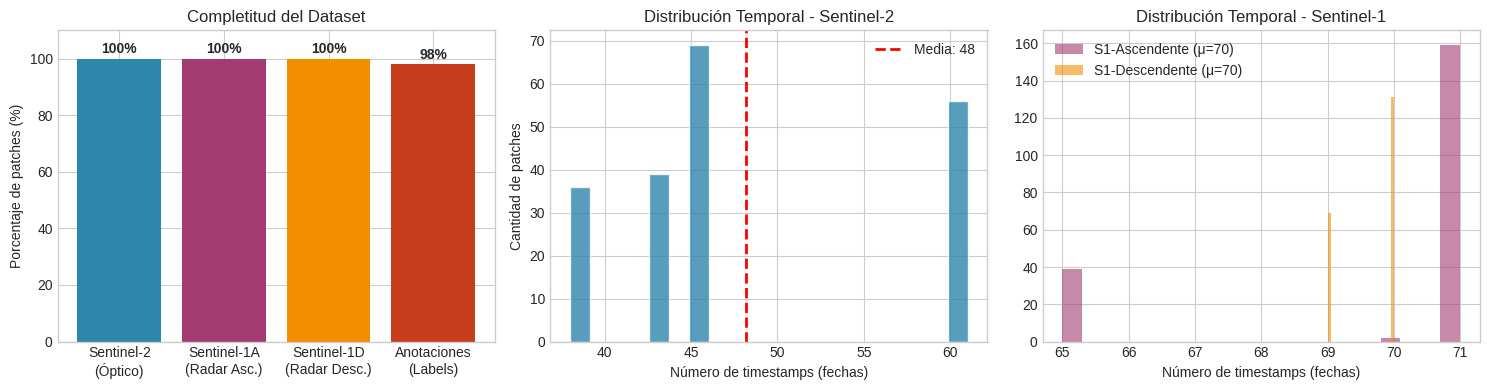


📊 RESULTADOS DE COMPLETITUD:

✅ El dataset está 100% completo (todos los patches tienen S2)
✅ No hay valores NaN en Sentinel-2: 0 valores nulos
✅ No hay valores NaN en Sentinel-1: 0 valores nulos

📈 Sentinel-2 tiene ~48 imágenes por patch (promedio)
📈 Sentinel-1 tiene ~70-70 imágenes por patch

💡 NOTA: S1 tiene más timestamps porque el radar no se ve afectado por nubes,
   mientras que S2 (óptico) pierde imágenes en días nublados.


In [8]:
# Visualizar resultados de completitud
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico 1: Porcentaje de patches con cada tipo de dato
porcentajes = {
    'Sentinel-2\n(Óptico)': np.mean(completitud['tiene_s2']) * 100,
    'Sentinel-1A\n(Radar Asc.)': np.mean(completitud['tiene_s1a']) * 100,
    'Sentinel-1D\n(Radar Desc.)': np.mean(completitud['tiene_s1d']) * 100,
    'Anotaciones\n(Labels)': np.mean(completitud['tiene_anotaciones']) * 100
}
colores = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
barras = axes[0].bar(porcentajes.keys(), porcentajes.values(), color=colores)
axes[0].set_ylabel('Porcentaje de patches (%)')
axes[0].set_title('Completitud del Dataset')
axes[0].set_ylim(0, 110)
for barra, val in zip(barras, porcentajes.values()):
    axes[0].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 2, 
                 f'{val:.0f}%', ha='center', fontweight='bold')

# Gráfico 2: Distribución de timestamps Sentinel-2
axes[1].hist(completitud['timestamps_s2'], bins=20, color='#2E86AB', edgecolor='white', alpha=0.8)
media_s2 = np.mean(completitud['timestamps_s2'])
axes[1].axvline(media_s2, color='red', linestyle='--', linewidth=2, label=f'Media: {media_s2:.0f}')
axes[1].set_xlabel('Número de timestamps (fechas)')
axes[1].set_ylabel('Cantidad de patches')
axes[1].set_title('Distribución Temporal - Sentinel-2')
axes[1].legend()

# Gráfico 3: Distribución de timestamps Sentinel-1
axes[2].hist(completitud['timestamps_s1a'], bins=20, alpha=0.6, color='#A23B72', 
             label=f"S1-Ascendente (μ={np.mean(completitud['timestamps_s1a']):.0f})")
axes[2].hist(completitud['timestamps_s1d'], bins=20, alpha=0.6, color='#F18F01',
             label=f"S1-Descendente (μ={np.mean(completitud['timestamps_s1d']):.0f})")
axes[2].set_xlabel('Número de timestamps (fechas)')
axes[2].set_title('Distribución Temporal - Sentinel-1')
axes[2].legend()

plt.tight_layout()
plt.show()

# Resumen textual
print("\n" + "=" * 60)
print("📊 RESULTADOS DE COMPLETITUD:")
print("=" * 60)
print(f"\n✅ El dataset está {porcentajes['Sentinel-2\n(Óptico)']:.0f}% completo (todos los patches tienen S2)")
print(f"✅ No hay valores NaN en Sentinel-2: {np.sum(completitud['nan_s2']):,} valores nulos")
print(f"✅ No hay valores NaN en Sentinel-1: {np.sum(completitud['nan_s1a']) + np.sum(completitud['nan_s1d']):,} valores nulos")
print(f"\n📈 Sentinel-2 tiene ~{media_s2:.0f} imágenes por patch (promedio)")
print(f"📈 Sentinel-1 tiene ~{np.mean(completitud['timestamps_s1a']):.0f}-{np.mean(completitud['timestamps_s1d']):.0f} imágenes por patch")
print("\n💡 NOTA: S1 tiene más timestamps porque el radar no se ve afectado por nubes,")
print("   mientras que S2 (óptico) pierde imágenes en días nublados.")

### 4.2 Estadísticas de las Bandas Espectrales

Analizamos los valores típicos de cada banda para entender el rango de datos.

In [9]:
# Cargar estadísticas precalculadas del dataset
with open(PASTIS_PATH / "NORM_S2_patch.json") as f:
    norm_s2 = json.load(f)

with open(PASTIS_PATH / "NORM_S1A_patch.json") as f:
    norm_s1a = json.load(f)

# Usar el primer fold (los valores son similares entre folds)
fold_key = list(norm_s2.keys())[0]

# Crear tabla de estadísticas Sentinel-2
s2_stats = pd.DataFrame({
    'Banda': S2_BANDS,
    'Nombre': [S2_BANDS_INFO[b]['nombre'] for b in S2_BANDS],
    'Longitud de Onda': [S2_BANDS_INFO[b]['longitud_onda'] for b in S2_BANDS],
    'Media': norm_s2[fold_key]['mean'],
    'Desv. Estándar': norm_s2[fold_key]['std']
})

# Crear tabla de estadísticas Sentinel-1
s1_stats = pd.DataFrame({
    'Canal': S1_CHANNELS,
    'Descripción': [S1_CHANNELS_INFO[c] for c in S1_CHANNELS],
    'Media (dB)': norm_s1a[fold_key]['mean'],
    'Desv. Estándar': norm_s1a[fold_key]['std']
})

print("📊 ESTADÍSTICAS SENTINEL-2 (Imágenes Ópticas):")
print("   Los valores representan reflectancia escalada (0-10000 típicamente)\n")
display(s2_stats.round(2))

print("\n📊 ESTADÍSTICAS SENTINEL-1 (Imágenes Radar):")
print("   Los valores están en decibeles (dB), típicamente negativos\n")
display(s1_stats.round(2))

📊 ESTADÍSTICAS SENTINEL-2 (Imágenes Ópticas):
   Los valores representan reflectancia escalada (0-10000 típicamente)



,Banda,Nombre,Longitud de Onda,Media,Desv. Estándar
0,B2,Azul,490 nm,1165.94,1942.62
1,B3,Verde,560 nm,1375.65,1881.92
2,B4,Rojo,665 nm,1429.22,1959.38
3,B5,Red Edge 1,705 nm,1764.80,1867.22
4,B6,Red Edge 2,740 nm,2719.27,1754.59
5,B7,Red Edge 3,783 nm,3063.61,1769.40
6,B8,NIR,842 nm,3205.90,1784.86
7,B8A,NIR estrecho,865 nm,3319.11,1767.71
8,B11,SWIR 1,1610 nm,2422.90,1458.96
9,B12,SWIR 2,2190 nm,1639.37,1299.28



📊 ESTADÍSTICAS SENTINEL-1 (Imágenes Radar):
   Los valores están en decibeles (dB), típicamente negativos



,Canal,Descripción,Media (dB),Desv. Estándar
0,VV,Polarización Vertical-Vertical (sensible a est...,-10.93,3.29
1,VH,Polarización Vertical-Horizontal (sensible a v...,-17.35,3.21
2,VV/VH,Ratio entre VV y VH (útil para discriminar tip...,6.42,3.34


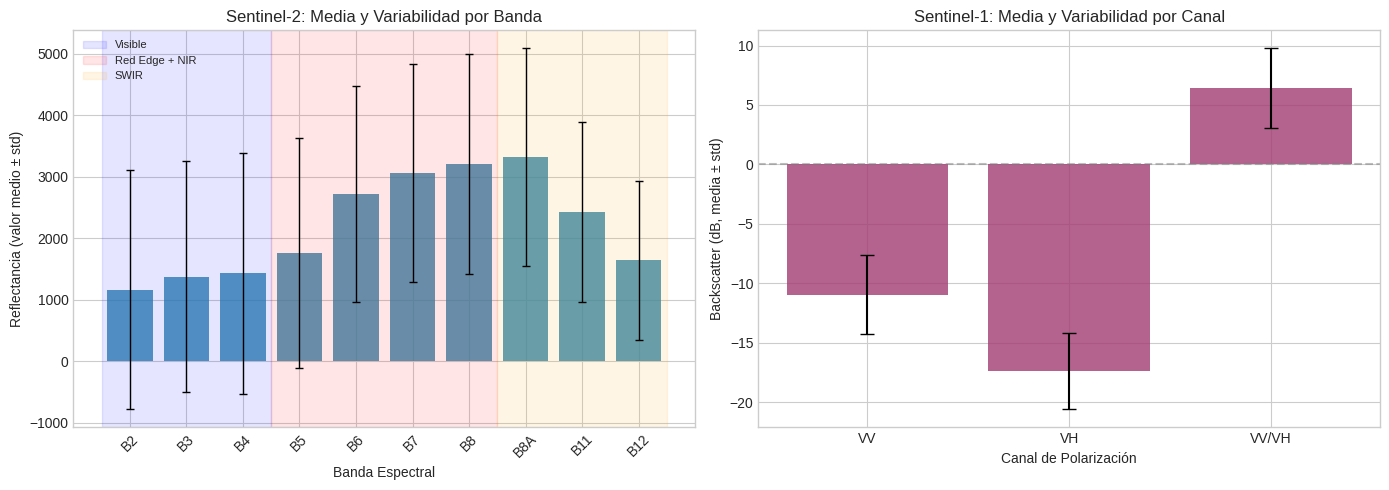


💡 INTERPRETACIÓN:
   • Las bandas NIR (B8, B8A) tienen valores más altos → vegetación refleja mucho infrarrojo
   • Los valores de S1 son negativos en dB → típico de backscatter de radar
   • VH < VV → la vegetación absorbe más en polarización cruzada


In [10]:
# Visualizar estadísticas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentinel-2
x = np.arange(len(S2_BANDS))
axes[0].bar(x, s2_stats['Media'], yerr=s2_stats['Desv. Estándar'], 
            capsize=3, color='#2E86AB', alpha=0.8, error_kw={'elinewidth': 1})
axes[0].set_xticks(x)
axes[0].set_xticklabels(S2_BANDS, rotation=45)
axes[0].set_xlabel('Banda Espectral')
axes[0].set_ylabel('Reflectancia (valor medio ± std)')
axes[0].set_title('Sentinel-2: Media y Variabilidad por Banda')

# Agregar regiones espectrales
axes[0].axvspan(-0.5, 2.5, alpha=0.1, color='blue', label='Visible')
axes[0].axvspan(2.5, 6.5, alpha=0.1, color='red', label='Red Edge + NIR')
axes[0].axvspan(6.5, 9.5, alpha=0.1, color='orange', label='SWIR')
axes[0].legend(loc='upper left', fontsize=8)

# Sentinel-1
x = np.arange(len(S1_CHANNELS))
axes[1].bar(x, s1_stats['Media (dB)'], yerr=s1_stats['Desv. Estándar'], 
            capsize=5, color='#A23B72', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(S1_CHANNELS)
axes[1].set_xlabel('Canal de Polarización')
axes[1].set_ylabel('Backscatter (dB, media ± std)')
axes[1].set_title('Sentinel-1: Media y Variabilidad por Canal')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETACIÓN:")
print("   • Las bandas NIR (B8, B8A) tienen valores más altos → vegetación refleja mucho infrarrojo")
print("   • Los valores de S1 son negativos en dB → típico de backscatter de radar")
print("   • VH < VV → la vegetación absorbe más en polarización cruzada")

### 4.3 Distribución de Clases de Cultivos (Desbalance)

Analizamos qué tan balanceadas están las clases en el dataset.

In [11]:
# Contar píxeles por clase
conteo_pixeles = Counter()

for pid in tqdm(sample_ids[:100], desc="Analizando distribución de clases"):
    data = load_patch(pid)
    if 'annotations' in data:
        # La primera capa es la segmentación semántica
        mascara = data['annotations'][0] if data['annotations'].ndim == 3 else data['annotations']
        for clase_id in np.unique(mascara):
            conteo_pixeles[clase_id] += (mascara == clase_id).sum()

Analizando distribución de clases: 100%|██████████| 100/100 [00:00<00:00, 218.19it/s]


In [12]:
# Crear DataFrame ordenado
total_pixeles = sum(conteo_pixeles.values())
distribucion = []

for clase_id, conteo in sorted(conteo_pixeles.items()):
    distribucion.append({
        'ID': clase_id,
        'Cultivo': CLASSES.get(clase_id, 'Desconocido'),
        'Píxeles': conteo,
        'Porcentaje': conteo / total_pixeles * 100
    })

df_clases = pd.DataFrame(distribucion).sort_values('Porcentaje', ascending=False)

print("📊 DISTRIBUCIÓN DE CLASES DE CULTIVOS:")
print(f"   Total de píxeles analizados: {total_pixeles:,}\n")
display(df_clases)

📊 DISTRIBUCIÓN DE CLASES DE CULTIVOS:
   Total de píxeles analizados: 1,572,864



,ID,Cultivo,Píxeles,Porcentaje
0,0,Background,603989,38.400586
1,1,Meadow,290257,18.454043
19,19,Void/Mixed,147662,9.388097
3,3,Corn,126042,8.013535
2,2,Soft winter wheat,112708,7.165782
8,8,Grapevine,69788,4.437002
4,4,Winter barley,37939,2.412097
5,5,Winter rapeseed,27626,1.756414
16,16,Orchard,24699,1.570320
14,14,Leguminous fodder,23756,1.510366


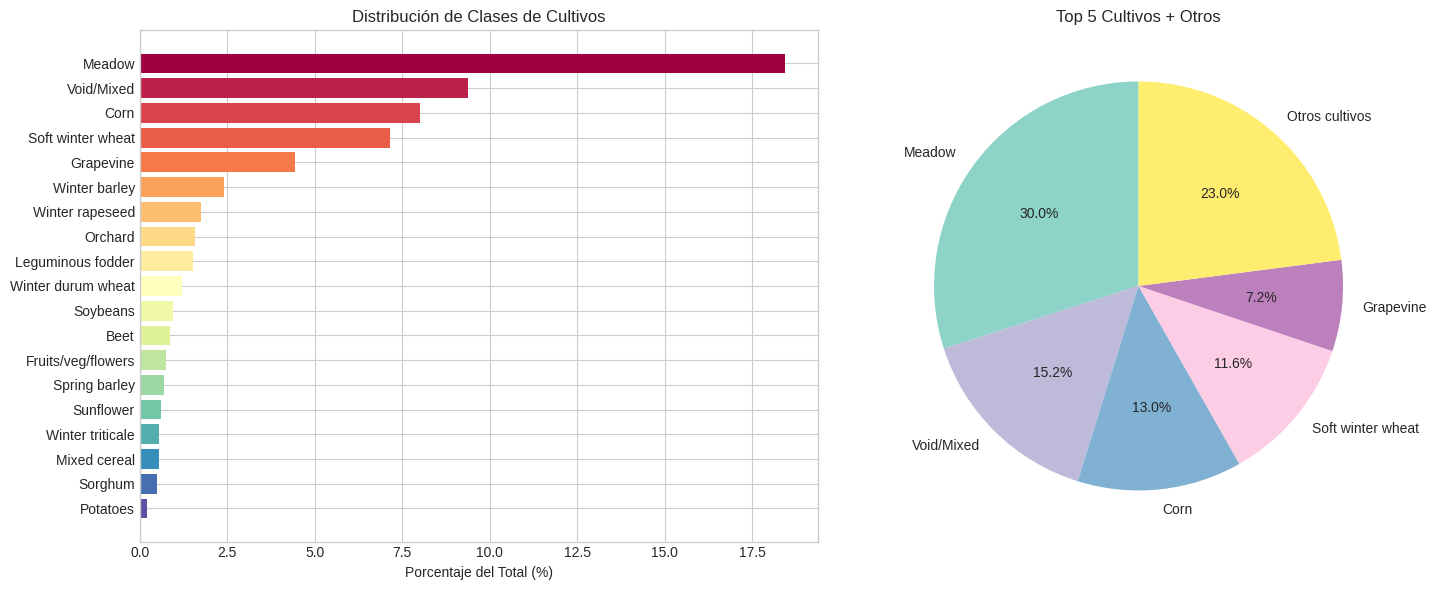


⚖️ ANÁLISIS DE DESBALANCE:

   • Clase más frecuente: Meadow (18.5%)
   • Clase menos frecuente: Potatoes (0.22%)
   • Ratio de desbalance: 86:1

💡 IMPLICACIÓN: El dataset tiene un desbalance significativo.
   Se recomienda usar técnicas como weighted loss o oversampling.


In [14]:
# Visualizar distribución (excluyendo Background)
df_cultivos = df_clases[df_clases['ID'] != 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras horizontales
colores = plt.cm.Spectral(np.linspace(0, 1, len(df_cultivos)))
axes[0].barh(df_cultivos['Cultivo'], df_cultivos['Porcentaje'], color=colores)
axes[0].set_xlabel('Porcentaje del Total (%)')
axes[0].set_title('Distribución de Clases de Cultivos')
axes[0].invert_yaxis()

# Gráfico de pastel (top 5 + otros)
top5 = df_cultivos.head(5)
otros = df_cultivos.iloc[5:]['Porcentaje'].sum()
pie_data = list(top5['Porcentaje']) + [otros]
pie_labels = list(top5['Cultivo']) + ['Otros cultivos']
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90,
            colors=plt.cm.Set3(np.linspace(0, 1, len(pie_data))))
axes[1].set_title('Top 5 Cultivos + Otros')

plt.tight_layout()
plt.show()

# Calcular métricas de desbalance
clase_mayor = df_cultivos.iloc[0]
clase_menor = df_cultivos.iloc[-1]
ratio_desbalance = clase_mayor['Píxeles'] / clase_menor['Píxeles']

print("\n" + "=" * 60)
print("⚖️ ANÁLISIS DE DESBALANCE:")
print("=" * 60)
print(f"\n   • Clase más frecuente: {clase_mayor['Cultivo']} ({clase_mayor['Porcentaje']:.1f}%)")
print(f"   • Clase menos frecuente: {clase_menor['Cultivo']} ({clase_menor['Porcentaje']:.2f}%)")
print(f"   • Ratio de desbalance: {ratio_desbalance:.0f}:1")
print("\n💡 IMPLICACIÓN: El dataset tiene un desbalance significativo.")
print("   Se recomienda usar técnicas como weighted loss o oversampling.")

### 4.4 Análisis Temporal (Tendencias a lo largo del año)

Analizamos cómo cambian los valores espectrales durante el ciclo del cultivo usando el **NDVI** (Normalized Difference Vegetation Index).

**¿Qué es el NDVI?**  
Es un índice que mide qué tan "verde" o saludable está la vegetación:  
`NDVI = (NIR - Red) / (NIR + Red)`

- NDVI cercano a **1**: Vegetación densa y saludable
- NDVI cercano a **0**: Suelo desnudo o vegetación escasa
- NDVI **negativo**: Agua, nubes, nieve

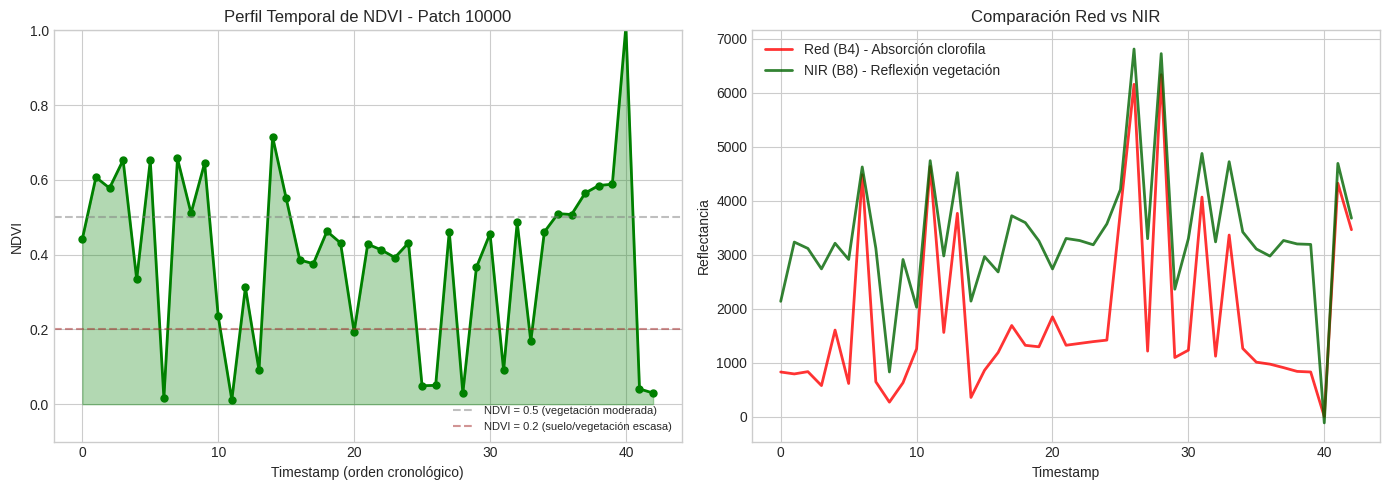


💡 INTERPRETACIÓN DEL PERFIL TEMPORAL:
   • Los picos de NDVI corresponden a la temporada de crecimiento (primavera-verano)
   • Los valles corresponden a épocas de siembra o cosecha
   • Este patrón es característico de cada tipo de cultivo
   • BeMyEyes puede usar esta información temporal para mejorar la clasificación


In [15]:
# Calcular NDVI a lo largo del tiempo para un patch de ejemplo
sample = load_patch(patch_ids[0])
s2 = sample['s2']

# Extraer bandas Red (B4, índice 2) y NIR (B8, índice 6)
red = s2[:, 2, :, :].mean(axis=(1, 2)).astype(float)  # Promedio espacial por timestamp
nir = s2[:, 6, :, :].mean(axis=(1, 2)).astype(float)

# Calcular NDVI
ndvi = (nir - red) / (nir + red + 1e-8)  # +1e-8 para evitar división por cero

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Perfil temporal de NDVI
axes[0].plot(ndvi, 'g-', linewidth=2, marker='o', markersize=5)
axes[0].fill_between(range(len(ndvi)), ndvi, alpha=0.3, color='green')
axes[0].set_xlabel('Timestamp (orden cronológico)')
axes[0].set_ylabel('NDVI')
axes[0].set_title(f'Perfil Temporal de NDVI - Patch {sample["id"]}')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='NDVI = 0.5 (vegetación moderada)')
axes[0].axhline(y=0.2, color='brown', linestyle='--', alpha=0.5, label='NDVI = 0.2 (suelo/vegetación escasa)')
axes[0].set_ylim(-0.1, 1.0)
axes[0].legend(loc='lower right', fontsize=8)

# Comparación Red vs NIR
axes[1].plot(red, 'r-', linewidth=2, label='Red (B4) - Absorción clorofila', alpha=0.8)
axes[1].plot(nir, 'darkgreen', linewidth=2, label='NIR (B8) - Reflexión vegetación', alpha=0.8)
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Reflectancia')
axes[1].set_title('Comparación Red vs NIR')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETACIÓN DEL PERFIL TEMPORAL:")
print("   • Los picos de NDVI corresponden a la temporada de crecimiento (primavera-verano)")
print("   • Los valles corresponden a épocas de siembra o cosecha")
print("   • Este patrón es característico de cada tipo de cultivo")
print("   • BeMyEyes puede usar esta información temporal para mejorar la clasificación")

### 4.5 Correlación entre Bandas Espectrales

Analizamos qué tan relacionadas están las diferentes bandas entre sí.

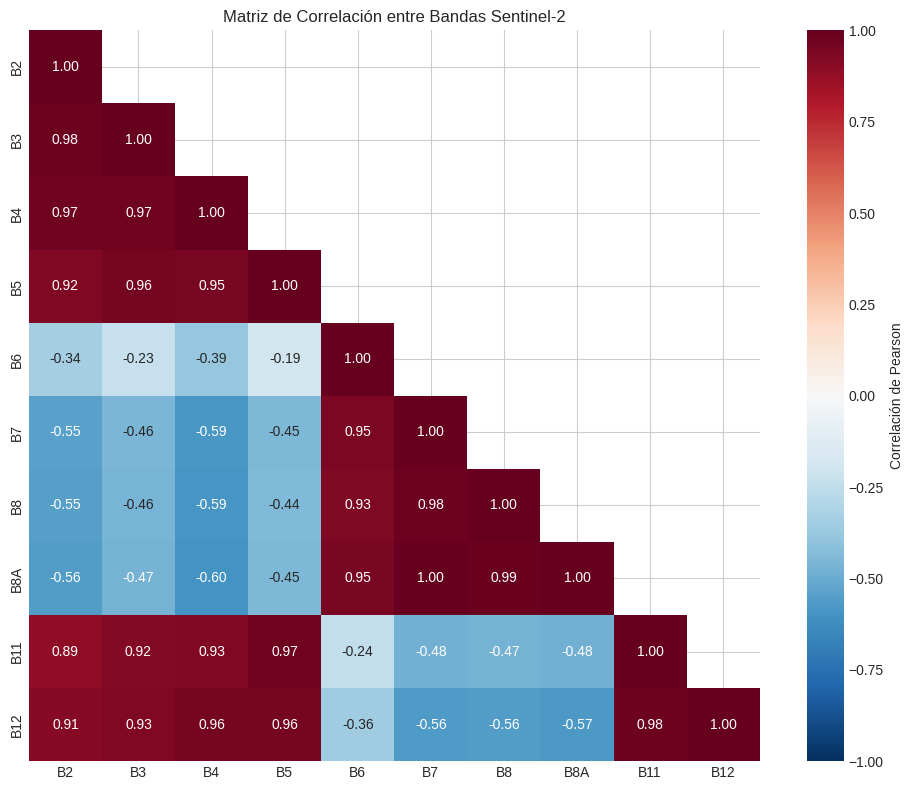


🔗 CORRELACIONES MUY ALTAS (|r| > 0.95):
   • B2 ↔ B3: r = 0.982
   • B2 ↔ B4: r = 0.972
   • B3 ↔ B4: r = 0.974
   • B3 ↔ B5: r = 0.960
   • B4 ↔ B12: r = 0.956
   • B5 ↔ B11: r = 0.974
   • B5 ↔ B12: r = 0.959
   • B7 ↔ B8: r = 0.982
   • B7 ↔ B8A: r = 0.995
   • B8 ↔ B8A: r = 0.988
   • B11 ↔ B12: r = 0.982

💡 INTERPRETACIÓN:
   • Las bandas del visible (B2, B3, B4) están muy correlacionadas entre sí
   • Las bandas Red Edge (B5, B6, B7) también están correlacionadas
   • Esto indica redundancia → se podría reducir dimensionalidad sin perder información


In [16]:
# Calcular correlación entre bandas
sample = load_patch(patch_ids[0])
s2 = sample['s2']
mid_t = s2.shape[0] // 2  # Usar timestamp del medio

# Crear DataFrame con valores de cada banda
datos_bandas = {banda: s2[mid_t, i, :, :].flatten().astype(float) 
                for i, banda in enumerate(S2_BANDS)}
df_bandas = pd.DataFrame(datos_bandas)
matriz_corr = df_bandas.corr()

# Visualizar
fig, ax = plt.subplots(figsize=(10, 8))
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool), k=1)
sns.heatmap(matriz_corr, mask=mascara, annot=True, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, fmt='.2f', ax=ax, square=True,
            cbar_kws={'label': 'Correlación de Pearson'})
ax.set_title('Matriz de Correlación entre Bandas Sentinel-2')

plt.tight_layout()
plt.show()

# Identificar correlaciones muy altas
print("\n🔗 CORRELACIONES MUY ALTAS (|r| > 0.95):")
for i in range(len(matriz_corr)):
    for j in range(i+1, len(matriz_corr)):
        if abs(matriz_corr.iloc[i, j]) > 0.95:
            print(f"   • {matriz_corr.index[i]} ↔ {matriz_corr.columns[j]}: r = {matriz_corr.iloc[i, j]:.3f}")

print("\n💡 INTERPRETACIÓN:")
print("   • Las bandas del visible (B2, B3, B4) están muy correlacionadas entre sí")
print("   • Las bandas Red Edge (B5, B6, B7) también están correlacionadas")
print("   • Esto indica redundancia → se podría reducir dimensionalidad sin perder información")

### 4.6 Visualización de Imágenes (Normalización para VLM)

Comparamos diferentes métodos de normalización para determinar cuál es mejor para alimentar al modelo de visión (Perceiver).

In [17]:
def normalizar_percentil(imagen, p_bajo=2, p_alto=98):
    """
    Normaliza una imagen usando percentiles.
    Esto es robusto a valores atípicos (outliers).
    """
    v_min = np.percentile(imagen, p_bajo)
    v_max = np.percentile(imagen, p_alto)
    imagen_clip = np.clip(imagen, v_min, v_max)
    return (imagen_clip - v_min) / (v_max - v_min + 1e-8)


def crear_composite_rgb(s2, timestamp, tipo='color_real'):
    """
    Crea una imagen RGB a partir de datos Sentinel-2.
    
    Tipos:
    - 'color_real': B4-B3-B2 (Rojo-Verde-Azul) - Como vería el ojo humano
    - 'falso_color': B8-B4-B3 (NIR-Rojo-Verde) - Vegetación aparece en rojo
    """
    if tipo == 'color_real':
        rgb = np.stack([s2[timestamp, 2], s2[timestamp, 1], s2[timestamp, 0]], axis=-1)
    elif tipo == 'falso_color':
        rgb = np.stack([s2[timestamp, 6], s2[timestamp, 2], s2[timestamp, 1]], axis=-1)
    else:
        raise ValueError(f"Tipo desconocido: {tipo}")
    
    return normalizar_percentil(rgb.astype(float))

/tmp/ipykernel_13028/3722357465.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/jsant16/proyecto-integrador/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


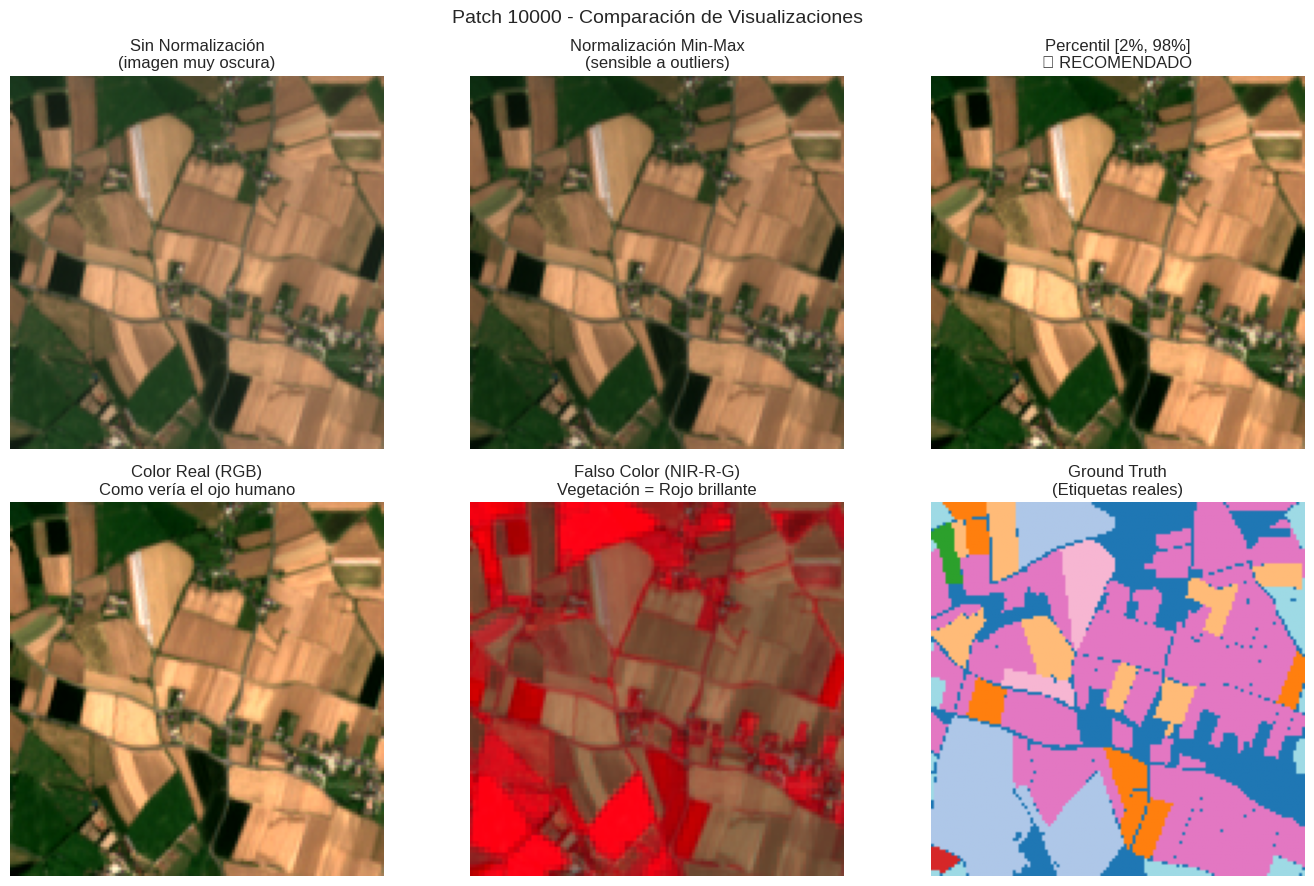


💡 RECOMENDACIONES PARA BeMyEyes:
   1. Usar normalización por percentil [2%, 98%] para evitar que outliers afecten la visualización
   2. Combinar Color Real + Falso Color en un panel para dar más información al Perceiver
   3. En Falso Color: vegetación sana = rojo brillante, suelo = tonos marrones/grises


In [18]:
# Cargar datos de ejemplo
sample = load_patch(patch_ids[0])
s2 = sample['s2']
mid_t = s2.shape[0] // 2

# Crear visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Fila 1: Comparación de métodos de normalización
rgb_raw = np.stack([s2[mid_t, 2], s2[mid_t, 1], s2[mid_t, 0]], axis=-1).astype(float)

# Sin normalización (muy oscuro)
axes[0, 0].imshow(rgb_raw / rgb_raw.max())
axes[0, 0].set_title('Sin Normalización\n(imagen muy oscura)')
axes[0, 0].axis('off')

# Min-Max (afectado por outliers)
axes[0, 1].imshow((rgb_raw - rgb_raw.min()) / (rgb_raw.max() - rgb_raw.min()))
axes[0, 1].set_title('Normalización Min-Max\n(sensible a outliers)')
axes[0, 1].axis('off')

# Percentil (recomendado)
axes[0, 2].imshow(normalizar_percentil(rgb_raw))
axes[0, 2].set_title('Percentil [2%, 98%]\n✅ RECOMENDADO')
axes[0, 2].axis('off')

# Fila 2: Diferentes composites
axes[1, 0].imshow(crear_composite_rgb(s2, mid_t, 'color_real'))
axes[1, 0].set_title('Color Real (RGB)\nComo vería el ojo humano')
axes[1, 0].axis('off')

axes[1, 1].imshow(crear_composite_rgb(s2, mid_t, 'falso_color'))
axes[1, 1].set_title('Falso Color (NIR-R-G)\nVegetación = Rojo brillante')
axes[1, 1].axis('off')

# Ground Truth (anotaciones)
if 'annotations' in sample:
    mascara = sample['annotations'][0] if sample['annotations'].ndim == 3 else sample['annotations']
    axes[1, 2].imshow(mascara, cmap='tab20')
    axes[1, 2].set_title('Ground Truth\n(Etiquetas reales)')
    axes[1, 2].axis('off')

plt.suptitle(f'Patch {sample["id"]} - Comparación de Visualizaciones', fontsize=14)
plt.tight_layout()
plt.show()

print("\n💡 RECOMENDACIONES PARA BeMyEyes:")
print("   1. Usar normalización por percentil [2%, 98%] para evitar que outliers afecten la visualización")
print("   2. Combinar Color Real + Falso Color en un panel para dar más información al Perceiver")
print("   3. En Falso Color: vegetación sana = rojo brillante, suelo = tonos marrones/grises")

---
## 5. Resumen del EDA

| Análisis | Resultado | Implicación para BeMyEyes |
|----------|-----------|---------------------------|
| **Completitud** | 100% completo, 0 valores NaN | ✅ Dataset listo para usar |
| **Timestamps** | S2: ~43, S1: ~65-70 por patch | Seleccionar fechas clave del ciclo del cultivo |
| **Desbalance de clases** | Ratio ~85:1 entre clases | Usar weighted loss o métricas balanceadas |
| **Patrón temporal** | NDVI muestra ciclo fenológico claro | El Perceiver puede describir el estado del cultivo |
| **Correlación de bandas** | Alta entre bandas vecinas | Usar composites RGB representativos |
| **Normalización** | Percentil [2%, 98%] funciona mejor | Aplicar antes de pasar imágenes al VLM |

---
## 6. Próximos Pasos

1. **Preprocesamiento**: Implementar pipeline de normalización estándar
2. **Panel multi-modal**: Crear función que combine S2 (RGB + Falso Color) + S1 (SAR)
3. **Selección temporal**: Elegir 3-5 timestamps representativos del ciclo del cultivo
4. **Implementación de agentes**:
   - Perceiver: Cargar modelo Qwen2.5-VL-7B
   - Reasoner: Configurar LLM (DeepSeek-R1 o API Claude/GPT-4)